# Baseline vs. Contextual Thompson Sampling

The bank contacts clients to offer a term deposit. We compare two policies on a
held-out eval split:

- **Baseline (deterministic):** always present the `cellular` offer (best historical channel) to every client.
- **Adaptive:** a **Contextual Thompson Sampling** bandit with three arms:
  `cellular`, `telephone` and `skip`, guided by a Logistic-Regression reward simulator.

Because the logged data only shows the channel each client actually received, we use a
simple Logistic Regression (`P(convert | client)`) as the **reward simulator** to
estimate the counterfactual reward of every (client, offer) pair.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from src.features import load_data, clean_data, build_preprocessor, split_data, FEATURE_COLUMNS
from src.simulator import RewardSimulator
from src.bandit import (
    ContextualThompsonSampling,
    replay_baseline,
    replay_contextual_bandit,
    recommend,
)

In [2]:
df = clean_data(load_data())
X, y = df[FEATURE_COLUMNS], df["y"]
X_train, X_eval, y_train, y_eval = split_data(X, y)
pre = build_preprocessor().fit(X_train)
X_train_t, X_eval_t = pre.transform(X_train), pre.transform(X_eval)

sim = RewardSimulator().fit(X_train_t, y_train, df_raw=df)
print("global conversion:", round(sim.base_rate_, 4))
print("channel lifts:", {k: round(v, 3) for k, v in sim.lifts_.items()})

global conversion: 0.117
channel lifts: {'cellular': 1.275, 'telephone': 1.147}


### Baseline — deterministic fixed rule

Rule: *always present the `cellular` offer to every client* (the best historical
channel). Reward = conversion (1 if the client subscribes, else 0).

In [3]:
base_rewards = replay_baseline(sim, X_eval_t, arm="cellular")
base_conv = float(np.mean(base_rewards))
print(f"Baseline (always cellular): conversion = {base_conv:.4f}")

Baseline (always cellular): conversion = 0.1467


### Adaptive policy — Contextual Thompson Sampling

- Clients are bucketed into **3 propensity segments** (tertiles of `P(convert)`,
  computed on the train split only).
- Each **(arm, segment)** keeps a `Beta(1,1)` posterior over its conversion rate.
- Per client: sample one conversion rate per arm from that segment's posterior,
  subtract the **contact cost** (0.07) for contact arms (`skip` scores 0), pick the
  arm with the highest score.
- Observe the (simulated) reward and update that (arm, segment) posterior.

This is Thompson Sampling made *contextual*: the platform treats client profiles
differently and learns to skip low-propensity clients whose contact does not pay off.

In [4]:
bandit = ContextualThompsonSampling(contact_cost=0.07).fit_segments(sim.propensity(X_train_t))
chosen, rewards, segs = replay_contextual_bandit(sim, X_eval_t, bandit)
contacted = [c != "skip" for c in chosen]
conv_contacted = float(np.mean([r for c, r in zip(chosen, rewards) if c != "skip"]))
contact_rate = float(np.mean(contacted))

print("arm counts:", {a: sum(1 for c in chosen if c == a) for a in bandit.arms})
print(f"TS conversion among contacted: {conv_contacted:.4f}  (baseline {base_conv:.4f})")
print(f"TS contacted {contact_rate:.1%} of clients")

arm counts: {'cellular': 7690, 'telephone': 2330, 'skip': 3544}
TS conversion among contacted: 0.1723  (baseline 0.1467)
TS contacted 73.9% of clients


### Evaluation (Etapa 4) — metrics and comparison

Conversion is measured *among the clients actually contacted* (the baseline contacts
everyone). We also report **net value** = conversions − contact cost × contacts, the
share of clients skipped, and the per-segment behaviour.

In [5]:
net_ts = float(np.sum(rewards) - bandit.contact_cost * sum(contacted))
net_base = float(np.sum(base_rewards) - bandit.contact_cost * len(X_eval_t))
improvement = (conv_contacted - base_conv) / base_conv

print("metrics on eval split:")
print(f"  baseline conversion (all clients):  {base_conv:.4f}")
print(f"  TS conversion (among contacted):    {conv_contacted:.4f}  ({improvement:+.1%} vs baseline)")
print(f"  TS contact rate:                    {contact_rate:.1%}  (saves {1 - contact_rate:.1%} of contacts)")
print(f"  net value  baseline:                {net_base:.1f}")
print(f"  net value  TS:                      {net_ts:.1f}")

for s in range(bandit.n_segments):
    m = [i for i in range(len(segs)) if segs[i] == s]
    sk = sum(1 for i in m if chosen[i] == "skip")
    print(f"segment {s}: {len(m):5d} clients  | skipped {sk:5d} | cellular {sum(1 for i in m if chosen[i] == 'cellular'):5d} | telephone {sum(1 for i in m if chosen[i] == 'telephone'):5d}")

metrics on eval split:
  baseline conversion (all clients):  0.1467
  TS conversion (among contacted):    0.1723  (+17.4% vs baseline)
  TS contact rate:                    73.9%  (saves 26.1% of contacts)
  net value  baseline:                1040.5
  net value  TS:                      1024.6
segment 0:  4427 clients  | skipped  3380 | cellular   696 | telephone   351
segment 1:  4585 clients  | skipped   164 | cellular  2691 | telephone  1730
segment 2:  4552 clients  | skipped     0 | cellular  4303 | telephone   249


### Exploration → exploitation

Cumulative conversion over the eval stream, and the rolling share of `cellular` /
`skip` decisions: the policy explores early (telephone, skip) and then concentrates
on the winning offer.

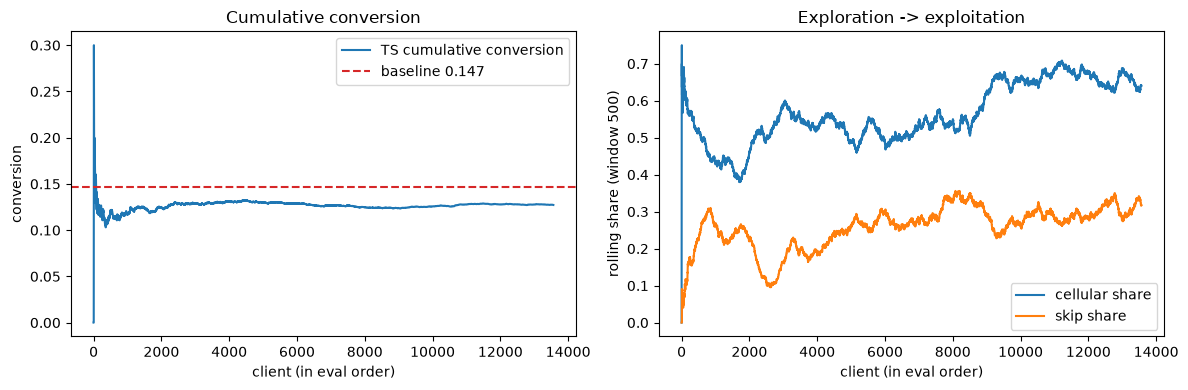

In [6]:
skip_share = pd.Series(chosen).eq("skip").rolling(500, min_periods=1).mean()
cell_share = pd.Series(chosen).eq("cellular").rolling(500, min_periods=1).mean()
cum_conv = pd.Series(rewards).cumsum() / (np.arange(len(rewards)) + 1)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].plot(cum_conv, label="TS cumulative conversion")
axes[0].axhline(base_conv, color="C3", ls="--", label=f"baseline {base_conv:.3f}")
axes[0].set(xlabel="client (in eval order)", ylabel="conversion", title="Cumulative conversion")
axes[0].legend()
axes[1].plot(cell_share, label="cellular share")
axes[1].plot(skip_share, label="skip share")
axes[1].set(xlabel="client (in eval order)", ylabel="rolling share (window 500)",
            title="Exploration -> exploitation")
axes[1].legend()
plt.tight_layout();

### Golden Set — 5 client examples

For each client we show the **recommended offer**, the client's propensity and the
rationale. At serving time we use the posterior **means** (exploit, deterministic).

In [7]:
golden = [
    # management, tertiary, previous campaign success -> high propensity
    {"age": 34, "job": "management", "marital": "married", "education": "tertiary",
     "default": "no", "housing": "yes", "loan": "no", "balance": 2500,
     "campaign": 1, "pdays": -1, "previous": 1, "poutcome": "success"},
    # blue-collar, secondary, unknown previous outcome -> mid propensity
    {"age": 41, "job": "blue-collar", "marital": "married", "education": "secondary",
     "default": "no", "housing": "yes", "loan": "no", "balance": 900,
     "campaign": 2, "pdays": -1, "previous": 0, "poutcome": "unknown"},
    # retired, primary, low balance, previous failure -> low propensity
    {"age": 58, "job": "retired", "marital": "married", "education": "primary",
     "default": "no", "housing": "yes", "loan": "no", "balance": 120,
     "campaign": 3, "pdays": 90, "previous": 2, "poutcome": "failure"},
    # technician, secondary, previous success -> mid/high propensity
    {"age": 29, "job": "technician", "marital": "single", "education": "secondary",
     "default": "no", "housing": "no", "loan": "no", "balance": 1800,
     "campaign": 1, "pdays": 6, "previous": 1, "poutcome": "success"},
    # services, secondary, unknown -> low propensity
    {"age": 47, "job": "services", "marital": "divorced", "education": "secondary",
     "default": "no", "housing": "yes", "loan": "yes", "balance": 300,
     "campaign": 4, "pdays": -1, "previous": 0, "poutcome": "unknown"},
]

rows = []
for cl in golden:
    rec = recommend(sim, bandit, pre, pd.DataFrame([cl])[FEATURE_COLUMNS])
    rows.append({
        "client": cl["job"],
        "propensity": rec["propensity"],
        "offer": rec["recommended_offer"],
        "expected_reward": rec["expected_reward"],
        "rationale": rec["rationale"],
    })

golden_df = pd.DataFrame(rows)
golden_df[["client", "propensity", "offer"]].assign(
    expected_reward=golden_df["expected_reward"].map(str),
    rationale=golden_df["rationale"].map(str),
)

,client,propensity,offer,expected_reward,rationale
0,management,0.5195,cellular,"{'cellular': 0.6625, 'telephone': 0.596, 'skip...",p=0.52; 'cellular' has the highest expected re...
1,blue-collar,0.0527,skip,"{'cellular': 0.0672, 'telephone': 0.0605, 'ski...",Low propensity to convert (p=0.05); the best c...
2,retired,0.1053,cellular,"{'cellular': 0.1343, 'telephone': 0.1208, 'ski...",p=0.11; 'cellular' has the highest expected re...
3,technician,0.6827,cellular,"{'cellular': 0.8706, 'telephone': 0.7831, 'ski...",p=0.68; 'cellular' has the highest expected re...
4,services,0.0393,skip,"{'cellular': 0.0502, 'telephone': 0.0451, 'ski...",Low propensity to convert (p=0.04); the best c...


### Conclusions

- The **Contextual Thompson Sampling** policy converts contacted clients at a higher
  rate than the fixed baseline while contacting **fewer** clients (cost savings).
- Context enters the decision through the propensity segments: low-propensity
  clients are skipped, high-propensity clients get the best offer.
- Exploration is visible early on and the policy converges to the best arm.
- The same pipeline is served as a small FastAPI (`/recommend`).